st3SickSym, meftDivNo,atcStep3Cd 

msupUseAmt
totUseQty


In [1]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt

con = duckdb.connect("healthcare.duckdb")
con.execute("PRAGMA threads=8")
con.execute("SET memory_limit='6GB'")

# =========================================================
# 실제 컬럼명
# =========================================================
COL = {
    "date": "diagYm",
    "disease": "st3SickSym",

    # 약효분류군
    "effect_code": "meftDivNo",
    "effect_name": "meftDivNoNm",

    # ATC3
    "atc3_code": "atcStep3Cd",
    "atc3_name": "atcStep3CdNm",

    # 시장규모 지표
    "amount": "msupUseQty",   # 실제 금액 컬럼으로 수정
    "quantity": "msupUseAmt", # 실제 수량 컬럼으로 수정
}

In [2]:
con.execute(f"""
SELECT
    MIN({COL["date"]}) AS min_ym,
    MAX({COL["date"]}) AS max_ym,
    COUNT(DISTINCT {COL["date"]}) AS month_count
FROM atc4_sick
""").fetchdf()


,min_ym,max_ym,month_count
0,202001,202212,36


In [3]:
meft_year = con.execute("""
WITH yearly AS (
    SELECT
        LEFT(CAST(diagYm AS VARCHAR), 4) AS year,
        meftDivNo,
        SUM(msupUseAmt) AS sum_qt,
        SUM(totUseQty) AS sum_amt
    FROM mefi_sick
    GROUP BY 1, 2
),

years AS (
    SELECT DISTINCT year
    FROM yearly
    ORDER BY year DESC
    LIMIT 3
),

annual AS (
    SELECT
        meftDivNo,

        MAX(CASE WHEN year = (SELECT MIN(year) FROM years)
                 THEN sum_amt END) AS y1_amt,

        MAX(CASE WHEN year = (
            SELECT year FROM years ORDER BY year LIMIT 1 OFFSET 1
        ) THEN sum_amt END) AS y2_amt,

        MAX(CASE WHEN year = (SELECT MAX(year) FROM years)
                 THEN sum_amt END) AS y3_amt

    FROM yearly
    WHERE year IN (SELECT year FROM years)
    GROUP BY meftDivNo
)

SELECT
    meftDivNo,
    y1_amt,
    y2_amt,
    y3_amt,

    y3_amt - y1_amt AS growth_amt,

    ROUND(
        100.0 * (y3_amt / NULLIF(y1_amt, 0) - 1),
        2
    ) AS growth_pct,

    CASE
        WHEN y1_amt < y2_amt
         AND y2_amt < y3_amt
        THEN TRUE
        ELSE FALSE
    END AS steadily_growing

FROM annual
WHERE y1_amt IS NOT NULL
  AND y2_amt IS NOT NULL
  AND y3_amt IS NOT NULL
ORDER BY growth_amt DESC
""").fetchdf()

meft_year.head(20)

,meftDivNo,y1_amt,y2_amt,y3_amt,growth_amt,growth_pct,steadily_growing
0,218,3.562780e+12,4.099093e+12,4.370894e+12,8.081140e+11,22.68,True
1,232,1.946299e+12,2.207121e+12,2.354223e+12,4.079245e+11,20.96,True
2,396,1.912711e+12,2.113081e+12,2.236066e+12,3.233549e+11,16.91,True
3,222,4.981714e+11,4.589437e+11,8.176372e+11,3.194658e+11,64.13,False
4,214,2.957579e+12,3.175095e+12,3.244751e+12,2.871725e+11,9.71,True
5,114,1.263721e+12,1.358778e+12,1.545192e+12,2.814705e+11,22.27,True
6,131,1.101677e+12,1.228404e+12,1.367577e+12,2.658998e+11,24.14,True
7,119,2.017405e+12,2.205743e+12,2.260376e+12,2.429714e+11,12.04,True
8,399,1.221638e+12,1.355124e+12,1.409214e+12,1.875758e+11,15.35,True
9,618,1.356621e+12,1.347496e+12,1.539382e+12,1.827614e+11,13.47,False


In [4]:
# ---------------------------------------------------------
# 1. 성장 분석 결과가 이미 meft_year에 있다고 가정
#
# meft_year columns:
# meftDivNo
# y1_amt
# y2_amt
# y3_amt
# growth_amt
# growth_pct
# steadily_growing
# ---------------------------------------------------------

# growth_amt Top 20
top_growth_amt = (
    meft_year
    .sort_values("growth_amt", ascending=False)
    .head(20)
    .copy()
)

# growth_pct Top 20
top_growth_pct = (
    meft_year
    .sort_values("growth_pct", ascending=False)
    .head(20)
    .copy()
)

# steadily_growing Top 20
top_steady = (
    meft_year[
        meft_year["steadily_growing"]
    ]
    .sort_values("growth_amt", ascending=False)
    .head(20)
    .copy()
)

target_codes = pd.concat([
    top_growth_amt[["meftDivNo"]],
    top_growth_pct[["meftDivNo"]],
    top_steady[["meftDivNo"]]
]).drop_duplicates()

target_codes = target_codes["meftDivNo"].tolist()

len(target_codes)

placeholders = ",".join(["?"] * len(target_codes))

name_map = con.execute(
    f"""
    SELECT
        meftDivNo,
        MAX(meftDivNoNm) AS meftDivNoNm
    FROM mefi_sick
    WHERE meftDivNo IN ({placeholders})
    GROUP BY meftDivNo
    """,
    target_codes
).fetchdf()

growth_amt_codes = set(top_growth_amt["meftDivNo"])
growth_pct_codes = set(top_growth_pct["meftDivNo"])
steady_codes = set(top_steady["meftDivNo"])

all_top = (
    meft_year[
        meft_year["meftDivNo"].isin(
            growth_amt_codes | growth_pct_codes | steady_codes
        )
    ]
    .merge(
        name_map,
        on="meftDivNo",
        how="left"
    )
    .copy()
)

all_top["in_growth_amt_top20"] = (
    all_top["meftDivNo"].isin(growth_amt_codes)
)

all_top["in_growth_pct_top20"] = (
    all_top["meftDivNo"].isin(growth_pct_codes)
)

all_top["in_steady_top20"] = (
    all_top["meftDivNo"].isin(steady_codes)
)

all_top = all_top.sort_values(
    ["growth_amt","growth_pct"],
    ascending=False
)

display(all_top)

,meftDivNo,y1_amt,y2_amt,y3_amt,growth_amt,growth_pct,steadily_growing,meftDivNoNm,in_growth_amt_top20,in_growth_pct_top20,in_steady_top20
0,218,3.562780e+12,4.099093e+12,4.370894e+12,8.081140e+11,22.68,True,동맥경화용제,True,True,True
1,232,1.946299e+12,2.207121e+12,2.354223e+12,4.079245e+11,20.96,True,소화성궤양용제,True,False,True
2,396,1.912711e+12,2.113081e+12,2.236066e+12,3.233549e+11,16.91,True,당뇨병용제,True,False,True
3,222,4.981714e+11,4.589437e+11,8.176372e+11,3.194658e+11,64.13,False,진해거담제,True,True,False
4,214,2.957579e+12,3.175095e+12,3.244751e+12,2.871725e+11,9.71,True,혈압강하제,True,False,True
5,114,1.263721e+12,1.358778e+12,1.545192e+12,2.814705e+11,22.27,True,해열·진통·소염제,True,True,True
6,131,1.101677e+12,1.228404e+12,1.367577e+12,2.658998e+11,24.14,True,안과용제,True,True,True
7,119,2.017405e+12,2.205743e+12,2.260376e+12,2.429714e+11,12.04,True,기타의 중추신경용약,True,False,True
8,399,1.221638e+12,1.355124e+12,1.409214e+12,1.875758e+11,15.35,True,따로 분류되지 않는 대사성 의약품,True,False,True
9,618,1.356621e+12,1.347496e+12,1.539382e+12,1.827614e+11,13.47,False,"주로 그람양성,음성균에 작용하는 것",True,False,False


In [5]:
steady_meft = (
    meft_year[
        meft_year["steadily_growing"]
    ]
    .sort_values("growth_amt", ascending=False)
)

steady_meft.head(20)

,meftDivNo,y1_amt,y2_amt,y3_amt,growth_amt,growth_pct,steadily_growing
0,218,3.562780e+12,4.099093e+12,4.370894e+12,8.081140e+11,22.68,True
1,232,1.946299e+12,2.207121e+12,2.354223e+12,4.079245e+11,20.96,True
2,396,1.912711e+12,2.113081e+12,2.236066e+12,3.233549e+11,16.91,True
4,214,2.957579e+12,3.175095e+12,3.244751e+12,2.871725e+11,9.71,True
5,114,1.263721e+12,1.358778e+12,1.545192e+12,2.814705e+11,22.27,True
6,131,1.101677e+12,1.228404e+12,1.367577e+12,2.658998e+11,24.14,True
7,119,2.017405e+12,2.205743e+12,2.260376e+12,2.429714e+11,12.04,True
8,399,1.221638e+12,1.355124e+12,1.409214e+12,1.875758e+11,15.35,True
10,142,9.190529e+11,1.074777e+12,1.092349e+12,1.732956e+11,18.86,True
11,241,1.828763e+11,2.324809e+11,2.970644e+11,1.141881e+11,62.44,True


In [6]:
large_growth_meft = (
    meft_year
    .sort_values(["growth_pct","growth_amt"], ascending=False)
)

large_growth_meft.head(10)

,meftDivNo,y1_amt,y2_amt,y3_amt,growth_amt,growth_pct,steadily_growing
53,116,2.672634e+08,5.135359e+08,1.724557e+09,1.457294e+09,545.27,True
59,729,2.998477e+08,2.937555e+08,7.688820e+08,4.690344e+08,156.42,False
22,115,5.122360e+10,6.555406e+10,8.537278e+10,3.414918e+10,66.67,True
56,252,1.725439e+09,2.195696e+09,2.867164e+09,1.141725e+09,66.17,True
3,222,4.981714e+11,4.589437e+11,8.176372e+11,3.194658e+11,64.13,False
11,241,1.828763e+11,2.324809e+11,2.970644e+11,1.141881e+11,62.44,True
45,231,9.528638e+09,9.575488e+09,1.420576e+10,4.677125e+09,49.08,True
25,237,6.691175e+10,7.351294e+10,9.144217e+10,2.453043e+10,36.66,True
21,619,1.208513e+11,1.073000e+11,1.639227e+11,4.307143e+10,35.64,False
17,141,2.027443e+11,2.073055e+11,2.686600e+11,6.591563e+10,32.51,True


In [ ]:
# import subprocess

# result = subprocess.run(
#     ["fc-list", ":lang=ko", "file", "family"],
#     capture_output=True,
#     text=True
# )

# print(result.stdout[:3000])

import subprocess

font_path = subprocess.check_output(
    ["fc-match", "Noto Serif CJK KR", "-f", "%{file}"]
).decode().strip()

print(font_path)

/usr/share/fonts/opentype/noto/NotoSansCJK-Bold.ttc: Noto Sans CJK TC
/usr/share/fonts/opentype/noto/NotoSansCJK-Bold.ttc: Noto Sans CJK SC
/usr/share/fonts/opentype/noto/NotoSansCJK-Bold.ttc: Noto Sans CJK JP
/usr/share/fonts/opentype/noto/NotoSansCJK-Bold.ttc: Noto Sans CJK HK
/usr/share/fonts/opentype/noto/NotoSansCJK-Bold.ttc: Noto Sans CJK KR
/usr/share/fonts/opentype/noto/NotoSansCJK-Bold.ttc: Noto Sans Mono CJK HK
/usr/share/fonts/opentype/noto/NotoSansCJK-Bold.ttc: Noto Sans Mono CJK KR
/usr/share/fonts/opentype/noto/NotoSansCJK-Bold.ttc: Noto Sans Mono CJK JP
/usr/share/fonts/opentype/noto/NotoSansCJK-Bold.ttc: Noto Sans Mono CJK TC
/usr/share/fonts/opentype/noto/NotoSansCJK-Bold.ttc: Noto Sans Mono CJK SC
/usr/share/fonts/opentype/noto/NotoSerifCJK-Regular.ttc: Noto Serif CJK HK
/usr/share/fonts/opentype/noto/NotoSerifCJK-Regular.ttc: Noto Serif CJK KR
/usr/share/fonts/opentype/noto/NotoSerifCJK-Regular.ttc: Noto Serif CJK JP
/usr/share/fonts/opentype/noto/NotoSerifCJK-Regula

Noto Sans CJK JP


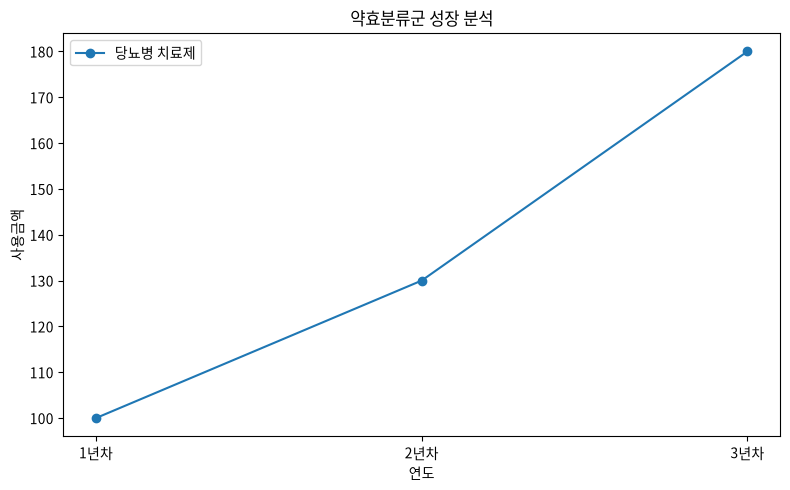

In [15]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

font_path = "/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc"

# 폰트 등록
fm.fontManager.addfont(font_path)

# 등록된 실제 이름 확인
font_name = fm.FontProperties(fname=font_path).get_name()
print(font_name)

# 전역 설정
plt.rcParams["font.family"] = font_name
plt.rcParams["axes.unicode_minus"] = False

plt.figure(figsize=(8, 5))

plt.plot(
    ["1년차", "2년차", "3년차"],
    [100, 130, 180],
    marker="o",
    label="당뇨병 치료제"
)

plt.title("약효분류군 성장 분석")
plt.xlabel("연도")
plt.ylabel("사용금액")
plt.legend()

plt.tight_layout()
plt.show()

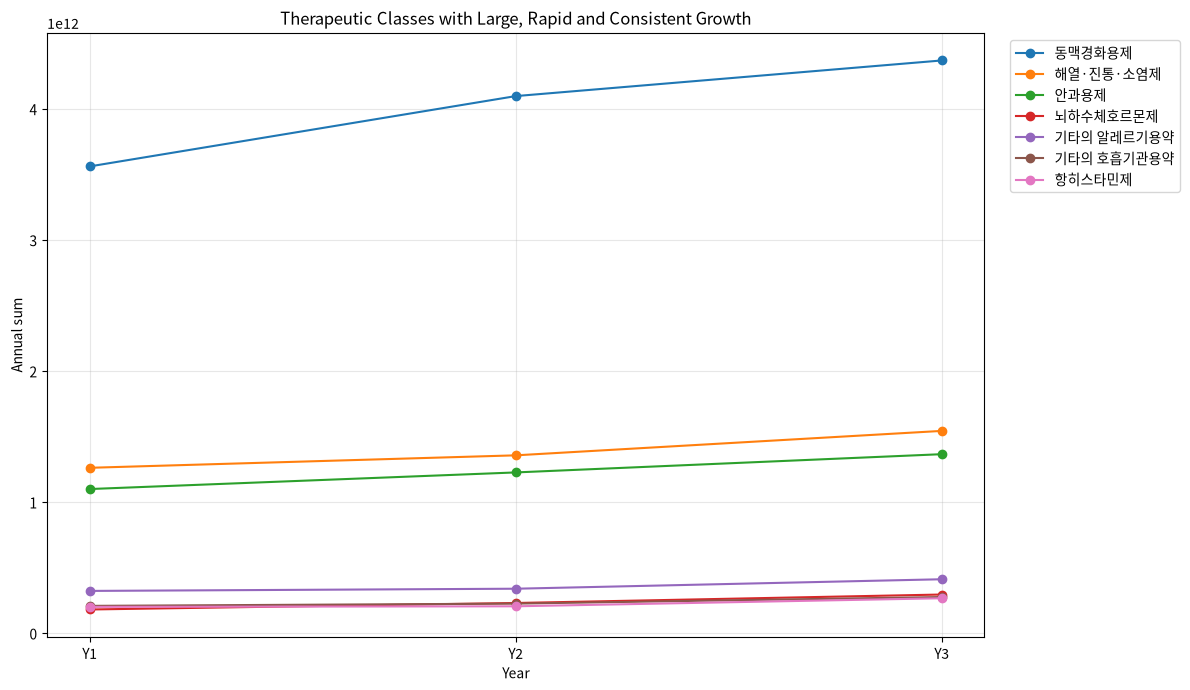

In [16]:
import matplotlib.pyplot as plt

# plt.rcParams["font.family"] = "Noto Serif CJK KR"
# plt.rcParams["axes.unicode_minus"] = False

core_plot = (
    all_top[
        all_top["in_growth_amt_top20"]
        & all_top["in_growth_pct_top20"]
        & all_top["in_steady_top20"]
    ]
    .sort_values("growth_amt", ascending=False)
)

plt.figure(figsize=(12, 7))

for _, row in core_plot.iterrows():

    plt.plot(
        ["Y1", "Y2", "Y3"],
        [
            row["y1_amt"],
            row["y2_amt"],
            row["y3_amt"]
        ],
        marker="o",
        label=row["meftDivNoNm"]
    )

plt.xlabel("Year")
plt.ylabel("Annual sum")
plt.title(
    "Therapeutic Classes with Large, Rapid and Consistent Growth"
)

plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

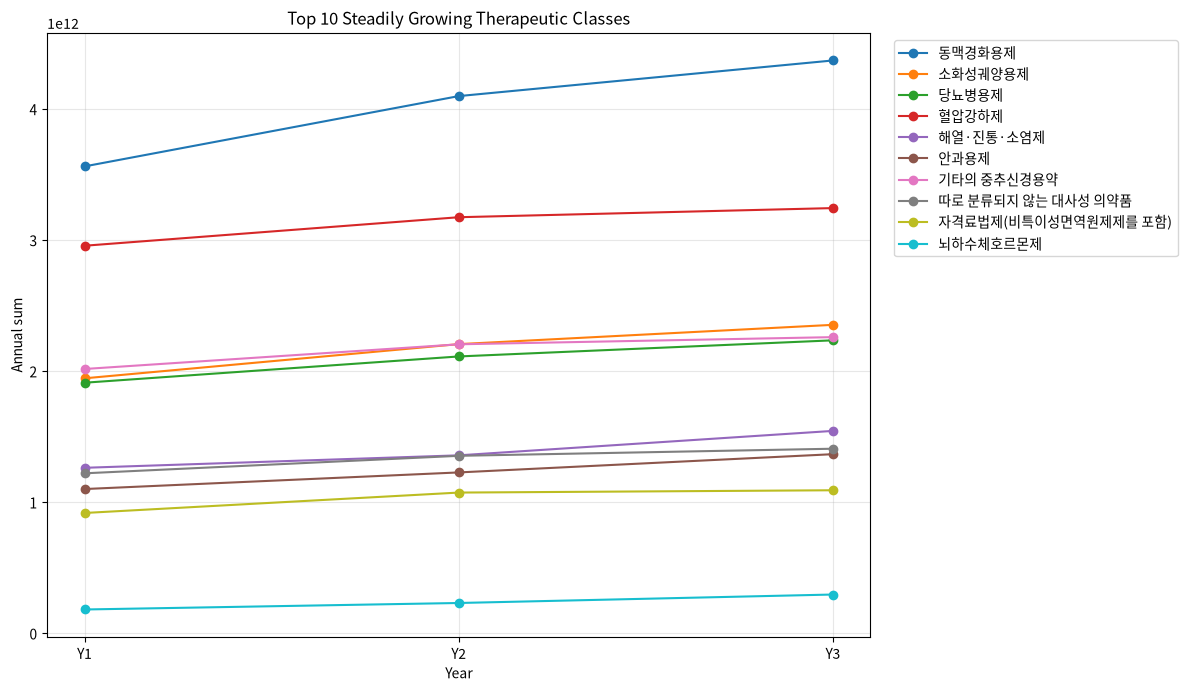

In [21]:
steady_plot = (
    all_top[
        all_top["in_steady_top20"]
    ]
    .sort_values("growth_amt", ascending=False)
    .head(10)
)

plt.figure(figsize=(12, 7))

for _, row in steady_plot.iterrows():

    plt.plot(
        ["Y1", "Y2", "Y3"],
        [
            row["y1_amt"],
            row["y2_amt"],
            row["y3_amt"]
        ],
        marker="o",
        label=row["meftDivNoNm"]
    )

plt.xlabel("Year")
plt.ylabel("Annual sum")
plt.title("Top 10 Steadily Growing Therapeutic Classes")

plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

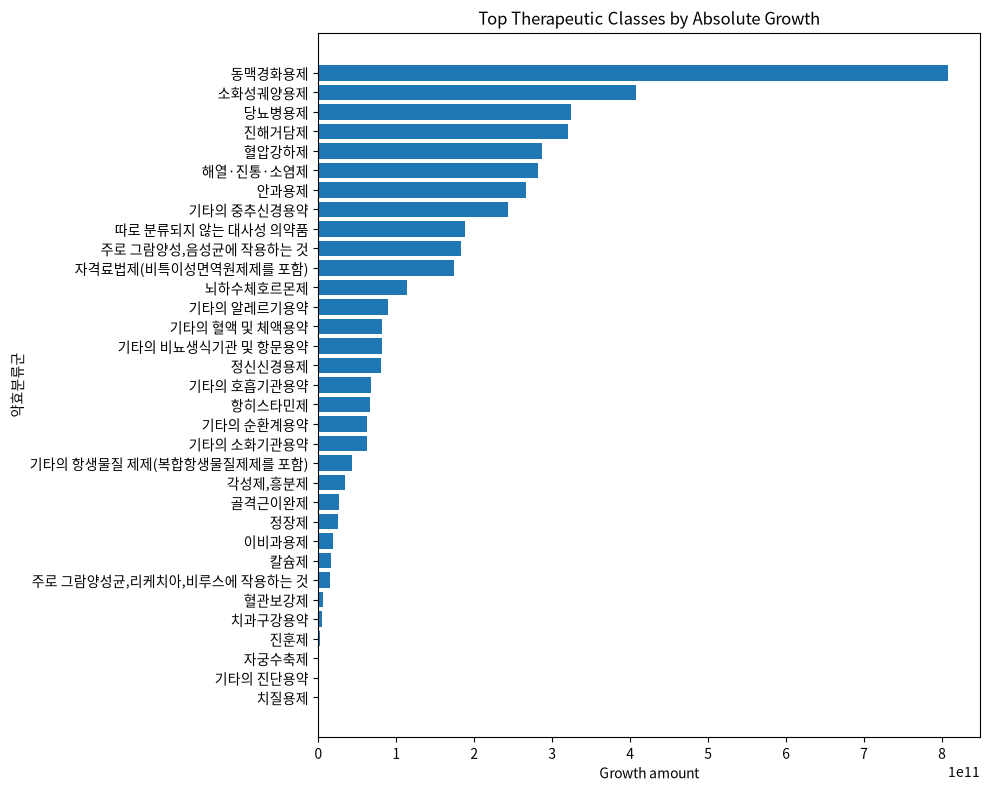

In [20]:
import matplotlib.pyplot as plt

plot_amt = (
    all_top
    .sort_values("growth_amt", ascending=True)
    .copy()
)

plt.figure(figsize=(10, 8))

plt.barh(
    plot_amt["meftDivNoNm"],
    plot_amt["growth_amt"]
)

plt.xlabel("Growth amount")
plt.ylabel("약효분류군")
plt.title("Top Therapeutic Classes by Absolute Growth")

plt.tight_layout()
plt.show()

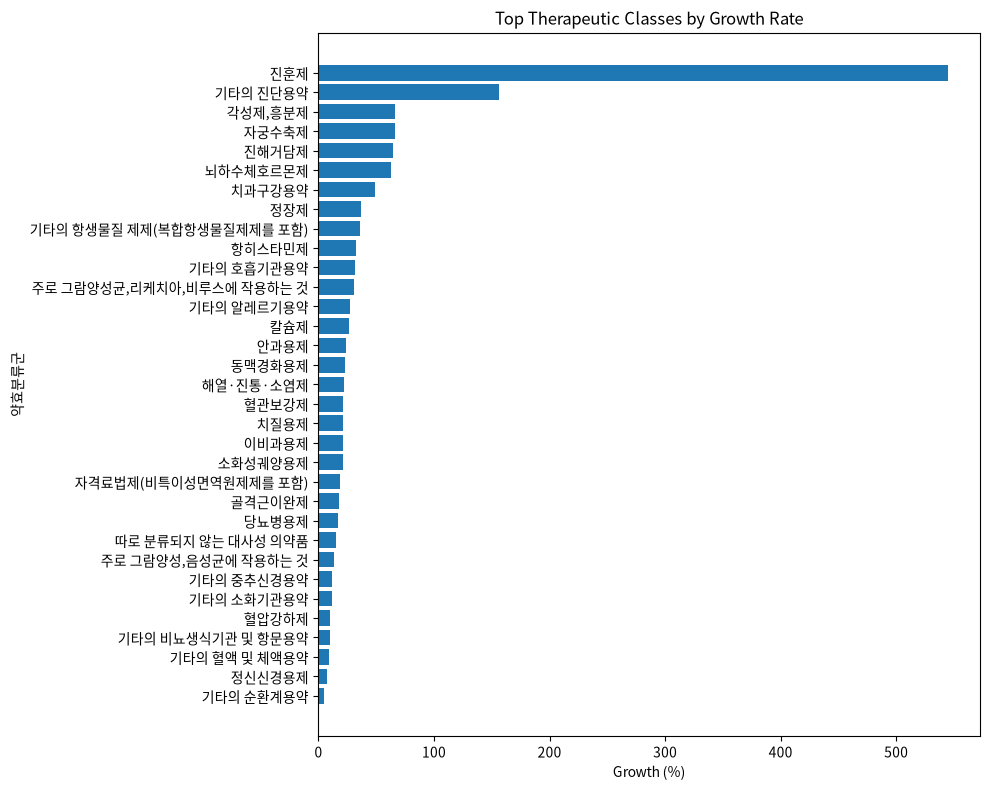

In [19]:
plot_pct = (
    all_top
    .sort_values("growth_pct", ascending=True)
    .copy()
)

plt.figure(figsize=(10, 8))

plt.barh(
    plot_pct["meftDivNoNm"],
    plot_pct["growth_pct"]
)

plt.xlabel("Growth (%)")
plt.ylabel("약효분류군")
plt.title("Top Therapeutic Classes by Growth Rate")

plt.tight_layout()
plt.show()